In [68]:
#Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import signal
from numpy.fft import fft, fftfreq, fftshift, ifft
pi = np.pi

In [69]:
#Carga del archivo eeg.mat
datos = scipy.io.loadmat('/content/drive/MyDrive/eeg.mat')
eeg = datos['x'].flatten()
fs = datos['fs'][0][0]
print(fs)
D=len(eeg)

256.0


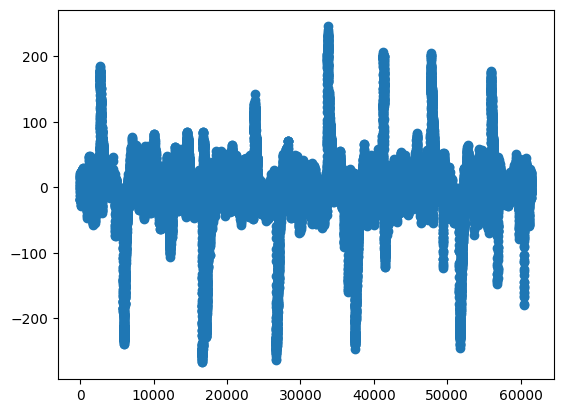

In [70]:
#Gráfica de tiempo discreto de la señal correspondiente en rad/muestra
Ts = 1 / fs
n = np.arange(0, len(eeg), 1)
plt.stem(n, eeg, basefmt="")
plt.show()

Text(0, 0.5, '|X(jΩ)|')

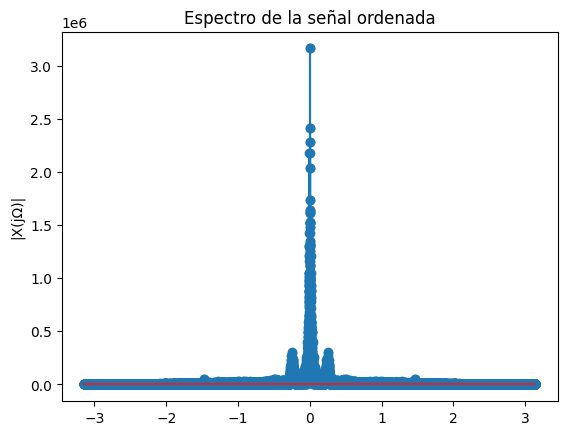

In [71]:
#Espectro de frecuencia del eeg
x_jΩ = fft(eeg)
N = len(t)
Ω = fftfreq(D, Ts)

Ω_ordenada = fftshift(Ω)
x_jΩ_ordenada = fftshift(x_jΩ)
plt.stem(2*pi*Ω_ordenada/fs,abs(x_jΩ_ordenada)*2*pi)
plt.title('Espectro de la señal ordenada')
plt.ylabel('|X(jΩ)|')

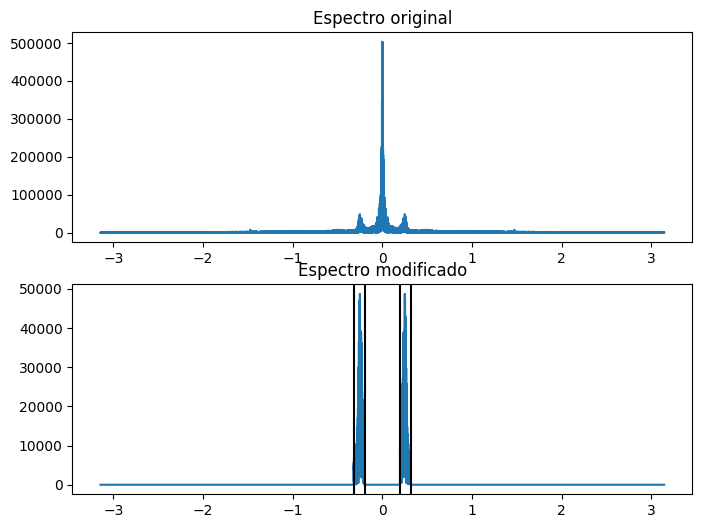

In [72]:
x_jΩ_modidicada = x_jΩ.copy()
#wc baja: 0.196 rad/muestra
#wc alta: 0.319 rad/muestra
x_jΩ_modidicada[abs(Ω)<8] = 0
x_jΩ_modidicada[(abs(Ω)>13)] = 0
plt.figure(figsize=(8,6))
#Espectro en frecuencia modificado y original con las debidas frecuencias de corte señalizadas
plt.subplot(2,1,1)
plt.plot(2*pi*fftshift(Ω)/fs,fftshift(abs(x_jΩ)))
plt.title('Espectro original')

plt.subplot(2,1,2)
plt.title('Espectro modificado')
plt.plot(2*pi*fftshift(Ω)/fs,fftshift(abs(x_jΩ_modidicada)))

plt.axvline(0.196, color='black')
plt.axvline(-0.196, color='black')
plt.axvline(0.319, color='black')
plt.axvline(-0.319, color='black')

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Señal original')

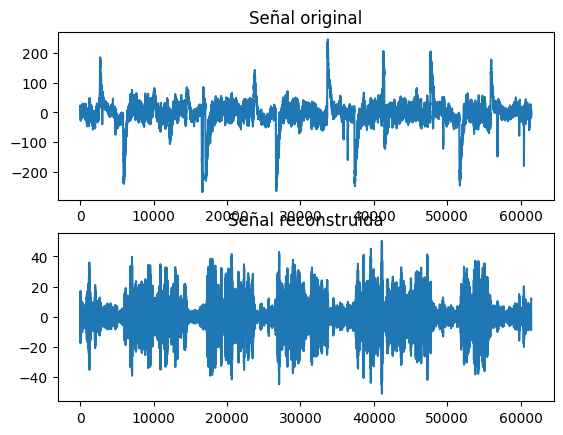

In [73]:
#Comparación del desempeño del filtrado a partir de las frecuencias de corte señalizadas
x_t_modif_reconstr = ifft(x_jΩ_modidicada)
plt.subplot(2,1,2)
plt.plot(n, x_t_modif_reconstr)
plt.title('Señal reconstruida')
plt.subplot(2,1,1)
plt.plot(n, eeg)
plt.title('Señal original')

Las ondas alfa se ven cuando los ojos están cerrados

In [74]:
#Se obtiene el orden y la frecuencia natural de los sistemas analógicos para poder realizar la simulación
O,Wn = signal.buttord(wp = [8*2*pi, 13*2*pi], ws=[2*2*pi, 21*2*pi], gpass= 3, gstop= 20 , analog= True)
print("Butterworth ", N, Wn, "\n")
O,Wn = signal.cheb1ord(wp = [8*2*pi, 13*2*pi], ws=[2*2*pi, 21*2*pi], gpass= 1, gstop= 20 , analog= True)
print("Chebyshev tipo I ", N, Wn, "\n")
O,Wn = signal.cheb2ord(wp = [8*2*pi, 13*2*pi], ws=[2*2*pi, 21*2*pi], gpass= 3, gstop= 20 , analog= True)
print("Chebyshev tipo II ", N, Wn, "\n")
O,Wn = signal.ellipord(wp = [8*2*pi, 13*2*pi], ws=[2*2*pi, 21*2*pi], gpass= 3, gstop= 20 , analog= True)
print("Elipse ", N, Wn)

Butterworth  61441 [50.2512677 81.7045145] 

Chebyshev tipo I  61441 [50.26548246 81.68140899] 

Chebyshev tipo II  61441 [ 37.09475071 110.68292286] 

Elipse  61441 [50.26548246 81.68140899]


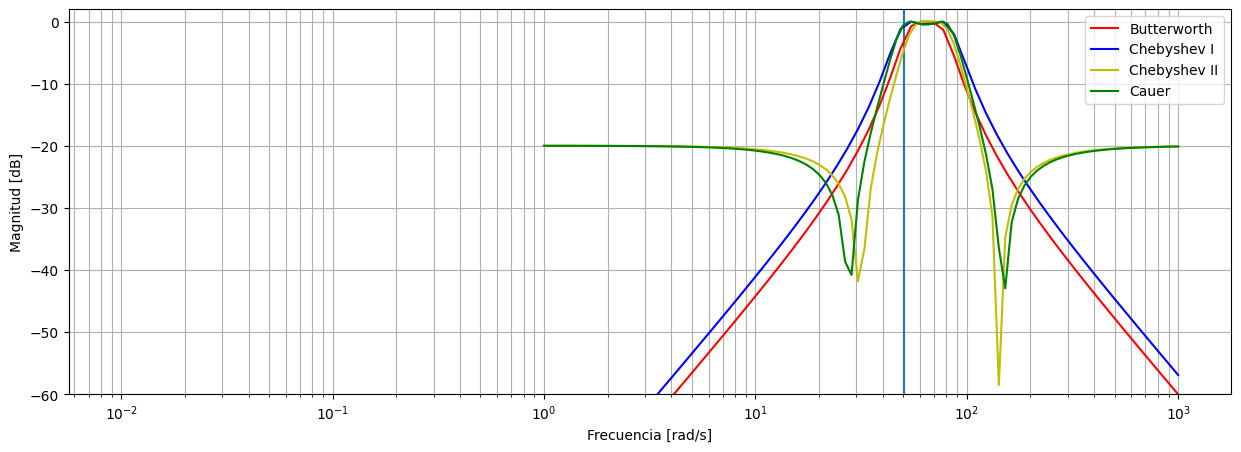

In [75]:
ΩL=8*2*pi
ΩH=13*2*pi
N=2
rp=0.5
rs=20
tipo='bandpass'
#Se realiza la simulación de los sistemas analógicos y obtenemos su diagrama de bode
b_butt, a_butt = signal.butter(N,  [ΩL,ΩH], btype=tipo, analog=True, output='ba', fs=None)
b_cheby1, a_cheby1 = signal.cheby1(N, rp, [ΩL,ΩH], btype=tipo, analog=True, output='ba', fs=None)
b_cheby2, a_cheby2 = signal.cheby2(N, rs, [ΩL-12,ΩH+35], btype=tipo, analog=True, output='ba', fs=None)
b_cauer, a_cauer = signal.ellip(N, rp, rs, [ΩL,ΩH], btype=tipo, analog=True, output='ba', fs=None)

H_butt = signal.TransferFunction(b_butt, a_butt)
H_cheby1 = signal.TransferFunction(b_cheby1, a_cheby1)
H_cheby2 = signal.TransferFunction(b_cheby2, a_cheby2)
H_cauer = signal.TransferFunction(b_cauer, a_cauer)

frec_butt,magnitud_butt,fase_butt=signal.bode(H_butt)
frec_cheby1,magnitud_cheby1,fase_cheby1=signal.bode(H_cheby1)
frec_cheby2,magnitud_cheby2,fase_cheby2=signal.bode(H_cheby2)
frec_cauer,magnitud_cauer,fase_cauer=signal.bode(H_cauer)
#Se elige el Chebyshev I de forma errónea y se lleva a cabo todo el procedimiento de la práctica cuando en realidad se tenía que tomar el Chebyshev II el cual cumple con los requisitos mínimos de criterios para el filtro
plt.figure(figsize=(15,5))
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [rad/s]')
plt.ylim(-60,2)
plt.axvline(8*2*pi)
plt
plt.semilogx(frec_butt,magnitud_butt,color='r', label='Butterworth')
plt.semilogx(frec_cheby1,magnitud_cheby1,color='b', label='Chebyshev I')
plt.semilogx(frec_cheby2,magnitud_cheby2,color='y', label='Chebyshev II')
plt.semilogx(frec_cauer,magnitud_cauer,color='g', label='Cauer')
plt.grid(True, which="both")
plt.legend()

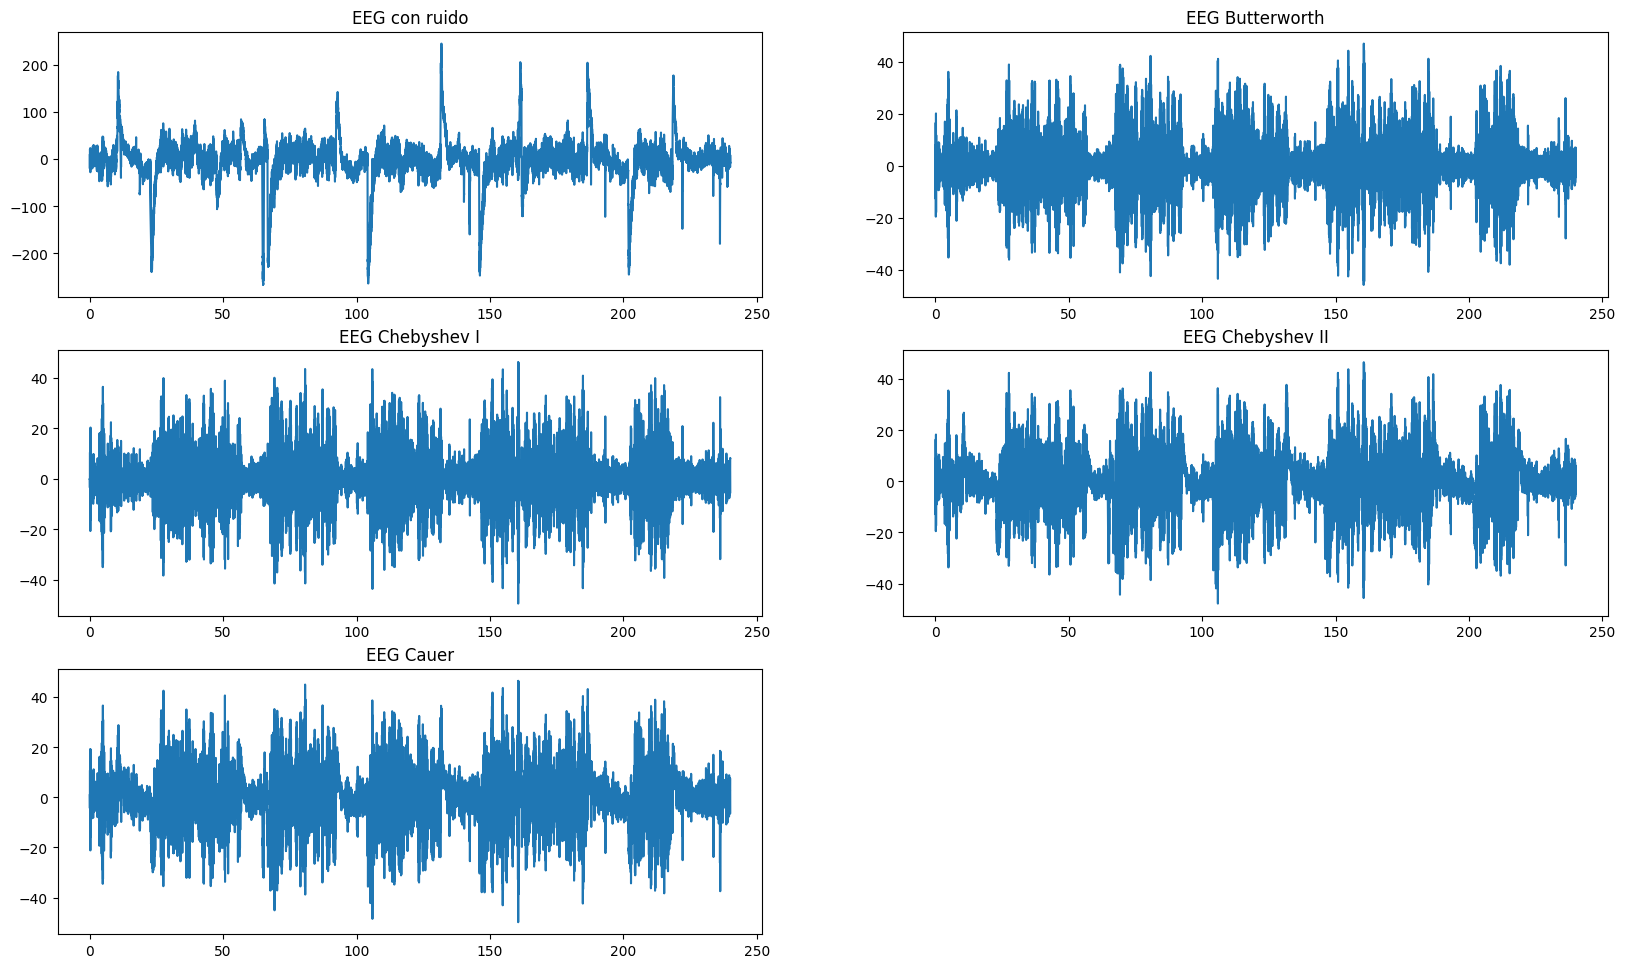

In [76]:
t1_butt, eeg_butt, _ = signal.lsim(H_butt,eeg,t)
t1_cheby1, eeg_cheby1, _ = signal.lsim(H_cheby1,eeg,t)
t1_cheby2, eeg_cheby2, _ = signal.lsim(H_cheby2,eeg,t)
t1_cauer, eeg_cauer, _ = signal.lsim(H_cauer,eeg,t)
#Al evaluar el desempeño de los filtros vemos que en general lo hacen bastante bien y continué el desarrollo con Cheby I pero debió ser Cheby II
plt.figure(figsize=(20,20))
plt.subplot(5,2,1)
plt.title('EEG con ruido')
plt.plot(t,eeg)
plt.subplot(5,2,2)
plt.title('EEG Butterworth')
plt.plot(t1_butt,eeg_butt)
plt.subplot(5,2,3)
plt.title('EEG Chebyshev I')
plt.plot(t1_cheby1,eeg_cheby1)
plt.subplot(5,2,4)
plt.title('EEG Chebyshev II')
plt.plot(t1_cheby2,eeg_cheby2)
plt.subplot(5,2,5)
plt.title('EEG Cauer')
plt.plot(t1_cauer,eeg_cauer)


### Se propone usar cheby 1 ya que se notan más los "paquetitos" de ondas alfa, en su defecto debió ser cheby 2 para el desarrollo digital

Text(0.5, 1.0, 'Respuesta al escalón analogico')

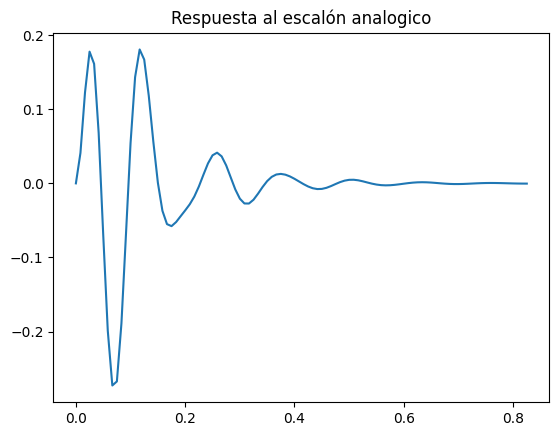

In [77]:
#Simulación de la respuesta al escalón analógico
n,y=signal.step(H_cheby1)
plt.plot(n,y)
plt.title("Respuesta al escalón analogico")


# Filtro digital

/usr/local/lib/python3.11/dist-packages/scipy/signal/_filter_design.py:1218: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)
/usr/local/lib/python3.11/dist-packages/scipy/signal/_filter_design.py:1458: ComplexWarning: Casting complex values to real discards the imaginary part
  sos[3-len(b):3] = b
/usr/local/lib/python3.11/dist-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


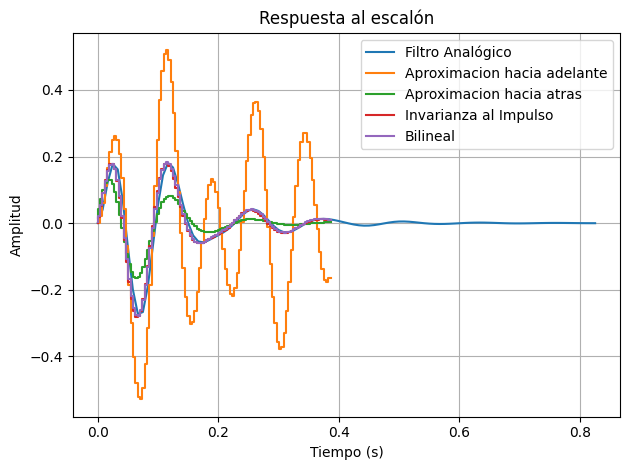

In [78]:
n,y=signal.step(H_cheby1)
plt.plot(n,y, label="Filtro Analógico")
#Se transforma la señal del cheby a digital a través del cont2discrete y se pasa de función de transferencia a secciones de segundo orden para posteriormente simular la respuesta al escalón de tiempo discreto para cada uno de los métodos señalados en los gráficos
dsys = signal.cont2discrete((b_cheby1, a_cheby1), Ts, method = 'euler') #Convierte de continuo a discreto usando el metodo de Euler: s = (z - 1) / T
Dnum = dsys[0].flatten()
Dden = dsys[1].flatten()
sos = signal.tf2sos(Dnum, Dden)
n, y_d = signal.dstep(dsys)
plt.step(n, y_d[0].flatten(), label = 'Aproximacion hacia adelante')

dsys = signal.cont2discrete((b_cheby1,a_cheby1),Ts,method='backward_diff') #Convierte de continuo a discreto usando: s = (1 - z^-1) / T
Dnum = dsys[0].flatten()
Dden = dsys[1].flatten()
sos = signal.tf2sos(Dnum, Dden)
n, y_d = signal.dstep(dsys)
plt.step(n, y_d[0].flatten(), label ='Aproximacion hacia atras')

dsys = signal.cont2discrete((b_cheby1,a_cheby1),Ts,method='impulse')
Dnum = dsys[0].flatten()
Dden = dsys[1].flatten()
sos = signal.tf2sos(Dnum, Dden)
n, y_d = signal.dstep(dsys)
plt.step(n, y_d[0].flatten(), label = 'Invarianza al Impulso')

dsys = signal.cont2discrete((b_cheby1,a_cheby1),Ts,method='bilinear') #Convierte de continuo a discreto usando: s = (2 / T) * (z - 1) / (z + 1)
Dnum = dsys[0].flatten()
Dden = dsys[1].flatten()
sos = signal.tf2sos(Dnum, Dden)
n, y_d = signal.dstep(dsys)
plt.step(n, y_d[0].flatten(), label = 'Bilineal')


plt.title("Respuesta al escalón")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

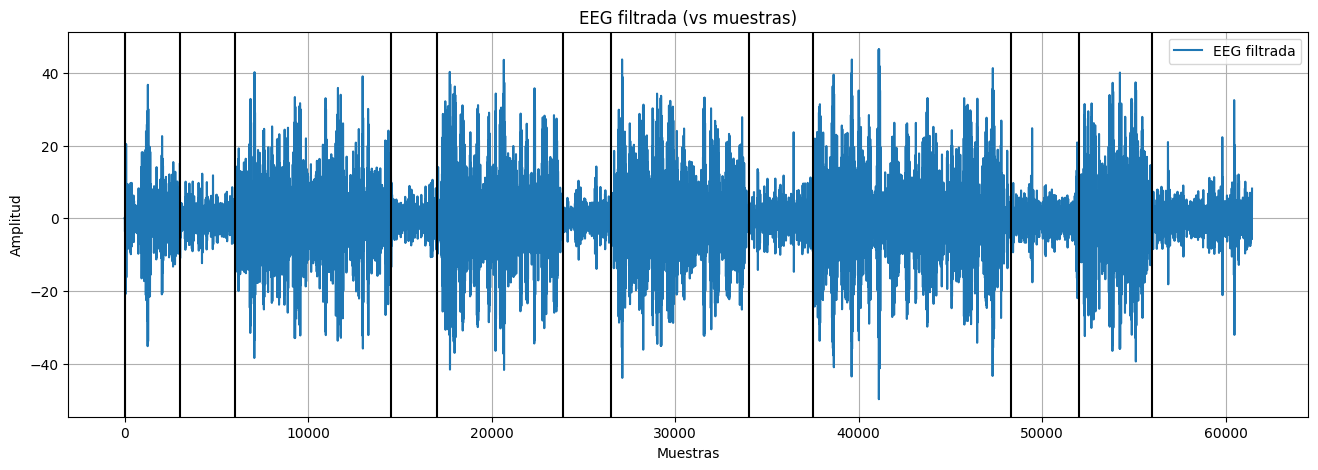

In [84]:
#Se había utilizado el metodo bilinear porque es el más estable y cercano al analógico y posteriormente se señalizaron todas las secciones donde estaban los ojos cerrados
dsys = signal.cont2discrete((b_cheby1,a_cheby1),Ts,method='bilinear')
Dnum = dsys[0].flatten()
Dden = dsys[1].flatten()
Deeg= signal.lfilter(Dnum, Dden, eeg)
n = np.arange(0, len(Deeg), 1)

plt.figure(figsize=(16, 5))
plt.plot(n, Deeg, label='EEG filtrada')
plt.title('EEG filtrada (vs muestras)')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.axvline(0,color='black')
plt.axvline(3000,color='black')
plt.axvline(6000,color='black')
plt.axvline(14500,color='black')
plt.axvline(17000,color='black')
plt.axvline(23900,color='black')
plt.axvline(26500,color='black')
plt.axvline(34000,color='black')
plt.axvline(37500,color='black')
plt.axvline(48300,color='black')
plt.axvline(52000,color='black')
plt.axvline(56000,color='black')
plt.show()